# VIIRS Nighttime Lights — Indonesia Night Lights Animation

**Dataset**: `NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG` (Google Earth Engine)
**Period**: January 2016 – December 2025 (120 months)
**Output**: Animated GIF, 0.5 seconds per frame (per month)

---

### What is VIIRS Nighttime Lights?
VIIRS (Visible Infrared Imaging Radiometer Suite) is a NOAA/NASA satellite sensor that records the intensity of artificial light at night (city lights, roads, industry, etc.). This data is commonly used to:
- Monitor urban growth and expansion
- Estimate electrification levels of an area
- Detect economic activity (e.g. industrial zones, ports)
- Study disaster impacts (e.g. large-scale power outages)

### What does this notebook do?
1. Fetches monthly nighttime light data for Indonesia from Google Earth Engine (GEE)
2. Adds visual annotations (title, month-year label, color legend, progress bar) to each frame
3. Combines all frames into a single **animated GIF** file
4. Displays an animation preview directly in the notebook
5. (Optional) Downloads the GIF / saves to Google Drive

### How to use
1. Run **Cell 1** first to install libraries & authenticate Google Earth Engine (only needed once per session)
2. Run the following cells **sequentially from top to bottom** — do not skip
3. Make sure you have an active **Google Earth Engine account** (register for free at https://earthengine.google.com/)
4. The data fetching process (Cell 6) takes several minutes as it calls the GEE server 120 times (once per month)

> This notebook is designed to run on **Google Colab**, but can also be run on local Jupyter as long as the required libraries (geemap, earthengine-api, etc.) are installed and GEE credentials are configured.


## Install & Authenticate Google Earth Engine

**Purpose of this cell:**
- Install/update all required Python libraries: `earthengine-api`, `geemap`, `Pillow`, `matplotlib`, `numpy`, `requests`, `tqdm`
- Authenticate with your Google Earth Engine account (a browser popup will appear for Google login)
- Initialize the Earth Engine session with your **Google Cloud Project ID**

**Important:**
- This cell only needs to be run **once per session** (once each time you open/restart the notebook). After successful authentication, you do not need to repeat it for the rest of the session.
- **Must be changed**: replace `'your-project-id'` in `ee.Initialize(project='your-project-id')` with your own Google Cloud Project ID. This ID can be found in the top-right corner of https://code.earthengine.google.com/ after logging in.
- If you don't have Earth Engine access yet, register for free at https://earthengine.google.com/.


In [1]:
# Install / update all required libraries
!pip install -q earthengine-api geemap Pillow matplotlib numpy requests tqdm geopandas fiona shapely
!pip install -q imageio[ffmpeg] moviepy

import ee

# Authenticate — a browser popup will appear, follow the instructions
ee.Authenticate()

# Initialize your GEE project
# Replace 'your-project-id' with your own Google Cloud Project ID
# (can be found at https://code.earthengine.google.com/ in the top-right corner)
ee.Initialize(project='ee-mahmudzakariyah4') #change with your project

print("Earth Engine initialized successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.9 MB/s eta 0:00:00
Earth Engine initialized successfully!


## Import Libraries

**Purpose of this cell:** load all Python modules that will be used in the following cells.

Summary of each library's function:
- `ee` & `geemap` → interact with Google Earth Engine (fetch satellite imagery)
- `numpy` → numerical operations (used indirectly through other dependencies)
- `matplotlib` → create image preview grids (used in Cell 11)
- `PIL` (`Image`, `ImageDraw`, `ImageFont`) → open downloaded images, draw text/annotations on them, and save as GIF
- `requests` & `io` → download thumbnail images from URLs provided by GEE
- `os` → file system operations (check file sizes, create folders, etc.)
- `tqdm` → progress bar while downloading multiple frames
- `IPython.display` → display images/GIFs directly in notebook output
- `warnings` → suppress unimportant warnings to keep output clean


In [2]:
# Import Libraries

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib import rcParams
from PIL import Image, ImageDraw, ImageFont
import requests
import io
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import mapping
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


## Parameter Configuration

**Purpose of this cell:** store all adjustable parameters in one place, making them easy to customize without modifying the logic in other cells.

Parameters defined here:
- `INDONESIA_BBOX` → bounding box coordinates covering Indonesia: longitude 94.0–141.5, latitude -11.5–6.5
- `COUNTRY_BORDERS_FC` & `BORDER_LINE_IMG` → **COUNTRY-level administrative borders** (not provincial) for Indonesia **and surrounding countries** (Malaysia, Singapore, Brunei, Philippines, Papua New Guinea, East Timor, Australia, Palau), sourced from the same Natural Earth shapefile, then rendered as thin lines over the nighttime light imagery (see Cell 4)
- `START_YEAR` / `END_YEAR` → year range for the data to be fetched (2016–2025)
- `VIZ_PARAMS` → image visualization parameters: the band displayed (`avg_rad`), radiation value range (`min`/`max`), and a color palette from black (dark) to white (very bright)
- `OUTPUT_GIF` → filename for the final GIF output
- `FRAME_DURATION` → display duration per frame in the GIF (in milliseconds)
- `IMG_WIDTH` / `IMG_HEIGHT` → resolution (width × height) of each frame
- `BULAN` → list of month names in Indonesian, used for labels on each frame

> To change the year range, color brightness, or image size, simply modify the values in this cell — no need to touch the code in other cells.


In [3]:
# Parameter Configuration

# Indonesia Region — from Shapefile
# Download Indonesia border SHP from Natural Earth (medium resolution)
import urllib.request, zipfile, pathlib

SHP_DIR = pathlib.Path('ne_shp')
SHP_DIR.mkdir(exist_ok=True)
SHP_ZIP = SHP_DIR / 'ne_10m_admin_0_countries.zip'

if not (SHP_DIR / 'ne_10m_admin_0_countries.shp').exists():
    url = 'https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip'
    print('Downloading Natural Earth shapefile (one-time only)...')
    urllib.request.urlretrieve(url, SHP_ZIP)
    with zipfile.ZipFile(SHP_ZIP) as zf:
        zf.extractall(SHP_DIR)
    print('Shapefile downloaded successfully.')

# Filter only Indonesia region & convert to GEE Geometry
gdf_world = gpd.read_file(str(SHP_DIR / 'ne_10m_admin_0_countries.shp'))
gdf_idn   = gdf_world[gdf_world['ADMIN'] == 'Indonesia'].copy()
gdf_idn   = gdf_idn.to_crs('EPSG:4326')

idn_geojson   = gdf_idn.geometry.iloc[0].__geo_interface__
INDONESIA_GEOM = ee.Geometry(idn_geojson)   # MultiPolygon of exact Indonesia boundary
# Bounding box still needed for GEE thumbnail region
INDONESIA_BBOX = ee.Geometry.Rectangle([94.0, -11.5, 141.5, 6.5])

# COUNTRY-level borders: Indonesia + surrounding countries
# NOTE: these are COUNTRY (national) administrative borders, NOT provincial borders.
NEIGHBORING_COUNTRIES = [
    'Malaysia', 'Singapore', 'Brunei', 'Philippines',
    'Papua New Guinea', 'East Timor', 'Palau',
]

gdf_tetangga = gdf_world[gdf_world['ADMIN'].isin(NEIGHBORING_COUNTRIES)].copy()
gdf_tetangga = gdf_tetangga.to_crs('EPSG:4326')

# Merge Indonesia polygon + neighboring country polygons into one collection
gdf_batas_negara = pd.concat([gdf_idn, gdf_tetangga], ignore_index=True)

# Convert each country polygon to ee.Feature, then merge into a FeatureCollection
_border_features = [
    ee.Feature(ee.Geometry(geom.__geo_interface__))
    for geom in gdf_batas_negara.geometry
]
COUNTRY_BORDERS_FC = ee.FeatureCollection(_border_features)

# "Paint" the outline of each country polygon as an ee.Image
# (paint with 3 arguments = outline only, not filled area)
BORDER_LINE_WIDTH = 1.2   # line width in pixels
BORDER_LINE_COLOR = 'b0b0b0'  # light gray — visible but doesn't dominate the image
BORDER_LINE_IMG = (
    ee.Image().byte()
    .paint(featureCollection=COUNTRY_BORDERS_FC, color=1, width=BORDER_LINE_WIDTH)
    .selfMask()
)

# Data period
START_YEAR = 2016
END_YEAR   = 2025

# Visualization parameters
VIZ_PARAMS = {
    'bands': ['avg_rad'],
    'min': 0,
    'max': 15,           # nanoWatts/cm²/sr — adjust if needed
    'palette': [
        '#000004',       # purplish black — completely dark
        '#1f0c48',       # very dark purple
        '#570f6d',       # dark purple-magenta
        '#942667',       # magenta-red
        '#d24743',       # red-orange
        '#f88e1e',       # bright orange — city lights
        '#fcffa4',       # pale yellow — very bright
    ]
}

# Output
OUTPUT_GIF      = 'viirs_indonesia_2016_2025_V1.gif'
OUTPUT_MP4      = 'viirs_indonesia_2016_2025_4K_V1.mp4'
MP4_FPS         = 4               # frames per second for MP4 (120 frames ÷ 4 fps = 30 seconds)
MP4_BASE_WIDTH  = 3840            # target MP4 width (px) — change here if needed
MP4_BITRATE     = '20000k'        # video bitrate (20 Mbps — high quality)

FRAME_DURATION  = 300             # milliseconds per GIF frame
IMG_WIDTH       = 1000            # GIF/thumbnail frame width (px) — change here if needed

# Aspect ratio from bounding box (auto-calculated, do not change)
# Cosine correction: 1° of longitude is shorter at latitudes away from the equator.
# Indonesia's lat_mid ≈ -2.5° → cos(-2.5°) ≈ 0.999 → negligible effect,
# but still calculated for geographic accuracy.
import math as _math
_lon_span   = 141.5 - 94.0                                        # 47.5°
_lat_span   = 6.5   - (-11.5)                                     # 18.0°
_lat_mid    = (-11.5 + 6.5) / 2                                   # -2.5°
_aspect     = (_lon_span * _math.cos(_math.radians(_lat_mid))) / _lat_span

# Height is calculated from width to prevent map distortion (stretching)
# Rounded to even number (required by H.264 video encoder)
IMG_HEIGHT      = int(round(IMG_WIDTH  / _aspect / 2) * 2)
MP4_WIDTH       = MP4_BASE_WIDTH
MP4_HEIGHT      = int(round(MP4_BASE_WIDTH / _aspect / 2) * 2)
THUMBNAIL_DIMS  = [IMG_WIDTH, IMG_HEIGHT]

# Month labels
BULAN = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

print("Configuration complete!")
print(f"Period       : {START_YEAR} – {END_YEAR}")
print(f"Total frames : {(END_YEAR - START_YEAR + 1) * 12} frames")
print(f"Duration     : ~{(END_YEAR - START_YEAR + 1) * 12 * 0.3:.0f} seconds")
print(f"GIF res      : {IMG_WIDTH} × {IMG_HEIGHT} px  (aspect ratio {IMG_WIDTH/IMG_HEIGHT:.3f})")
print(f"MP4 res      : {MP4_WIDTH} × {MP4_HEIGHT} px  (aspect ratio {MP4_WIDTH/MP4_HEIGHT:.3f})")


Shapefile downloaded successfully.
Configuration complete!
Period       : 2016 – 2025
Total frames : 120 frames
Duration     : ~36 seconds
GIF res      : 1000 × 380 px  (aspect ratio 2.632)
MP4 res      : 3840 × 1456 px  (aspect ratio 2.637)


## Fetch Thumbnail from GEE

**Purpose of this cell:** define the `get_monthly_thumbnail(year, month)` function, which will be called repeatedly (120 times, once per month) to fetch nighttime light images from Earth Engine.

**How the function works:**
1. Determines the start and end dates of the requested month (end date is calculated automatically, including the special case of December → January of the next year)
2. Creates an `ImageCollection` from the VIIRS dataset, then filters by date and Indonesia's region
3. Combines (`mosaic()`) all images within the time range into a single image, then clips it (`clip()`) to Indonesia's boundaries
4. Requests a PNG thumbnail URL from GEE using the visualization parameters defined in Cell 3
5. **Country border overlay**: the image is first visualized (`.visualize()`) as RGB, then blended (`.blend()`) with `BORDER_LINE_IMG` (Indonesia + neighboring country borders from Cell 3), burning the border lines into the image — these are COUNTRY borders, not provincial
6. Downloads the image from that URL using `requests`, then converts it to a `PIL.Image` object
7. If an error occurs (e.g. connection failure or no data available), the function prints a warning and returns `None` — this is handled in Cell 6 with a black placeholder frame


In [4]:
# Fetch Thumbnail from GEE

def get_monthly_thumbnail(year: int, month: int) -> Image.Image | None:
    """
    Fetch a PNG thumbnail from GEE for a specific month.
    Returns a PIL Image object, or None if the request fails.
    """
    start = f'{year}-{month:02d}-01'
    # End of month: use the next month as the boundary
    if month == 12:
        end = f'{year + 1}-01-01'
    else:
        end = f'{year}-{month + 1:02d}-01'

    collection = (
        ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
        .filterDate(start, end)
        .filterBounds(INDONESIA_BBOX)
        .select('avg_rad')
    )

    image = collection.mosaic().clip(INDONESIA_GEOM)

    # Render avg_rad to RGB using the color palette (VIZ_PARAMS)
    vis_image = image.visualize(**VIZ_PARAMS)

    # Overlay country borders (Indonesia + neighboring countries, from Cell 3)
    # on top of the nighttime light image — these are COUNTRY borders, not provincial
    border_vis  = BORDER_LINE_IMG.visualize(palette=[BORDER_LINE_COLOR])
    final_image = vis_image.blend(border_vis)

    url = final_image.getThumbURL({
        'region': INDONESIA_BBOX,
        'dimensions': f'{IMG_WIDTH}x{IMG_HEIGHT}',
        'format': 'png',
    })

    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert('RGB')
    except Exception as e:
        print(f"Failed to fetch {year}-{month:02d}: {e}")
        return None

print("Thumbnail function ready!")


Thumbnail function ready!


## Add Annotation to Frame

**Purpose of this cell:** define the `add_annotation()` function that adds informative visual elements to each raw frame, making the animation self-explanatory without needing external captions.

**Annotation elements added:**
- **Header (top left)** → title "VIIRS Nighttime Lights — Indonesia" and dataset source information
- **Month-year label (top right)** → e.g. "January 2016", so viewers know which frame is being displayed
- **Progress bar (bottom, full width)** → a gold-colored bar that extends according to the frame's position in the time sequence (0% at start, 100% at the last frame)
- **Color scale legend (bottom right)** → color gradient from black to white with "0" and "60+" labels as reference for light intensity (nW/sr/cm²)
- **Credit (bottom left)** → data source info: NOAA VIIRS/DNB & Google Earth Engine

This function also has a fallback mechanism: if the `DejaVuSans` font is not found on the system, it automatically uses PIL's default font to prevent errors.


In [5]:
# Add Annotation to Frame

def add_annotation(img: Image.Image, year: int, month: int,
                   frame_num: int, total_frames: int) -> Image.Image:
    """
    Add text overlays (title, month-year label, progress bar,
    color scale, and credit) to the image.
    """
    img = img.copy()
    draw = ImageDraw.Draw(img)
    W, H = img.size

    #  Colors
    C_BG        = (0, 0, 0, 180)      # semi-transparent black
    C_WHITE     = (255, 255, 255)
    C_BLACK     = (0, 0, 0)
    C_GOLD      = (255, 200, 50)
    C_GRAY      = (180, 180, 180)
    C_BAR_BG    = (50, 50, 50)
    C_BAR_FG    = (255, 200, 50)

    # Font (fallback to default if not available)
    try:
        font_title  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
        font_label  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 32)
        font_sub    = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
        font_credit = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 11)
    except IOError:
        font_title = font_label = font_sub = font_credit = ImageFont.load_default()

    # Header panel (top left)
    header_h = 55
    header_overlay = Image.new('RGBA', (W, header_h), (0, 0, 0, 160))
    img.paste(Image.new('RGB', (W, header_h), (0, 0, 0)), (0, 0),
              header_overlay)

    draw.text((14, 8),  "VIIRS Nighttime Lights Indonesia 2016 - 2025",
              font=font_title, fill=C_GOLD)
    draw.text((14, 32), "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG  |  avg_rad band",
              font=font_credit, fill=C_GRAY)

    # Month & year label (top right)
    label_text = f"{BULAN[month - 1]} {year}"
    bbox = draw.textbbox((0, 0), label_text, font=font_label)
    lw = bbox[2] - bbox[0]
    draw.text((W - lw - 14, 10), label_text, font=font_label, fill=C_WHITE)

    # Progress bar (bottom)
    bar_h    = 6
    bar_y    = H - bar_h
    progress = frame_num / total_frames
    draw.rectangle([0, bar_y, W, H], fill=C_BAR_BG)
    draw.rectangle([0, bar_y, int(W * progress), H], fill=C_BAR_FG)

    # Color scale legend (bottom right)
    legend_w, legend_h = 160, 18
    legend_x, legend_y = W - legend_w - 12, H - 40

    # Color gradient
    palette_colors = [
        (0, 0, 4),
        (31, 12, 72),
        (87, 15, 109),
        (148, 38, 103),
        (210, 71, 67),
        (248, 142, 30),
        (252, 255, 164)
    ]
    for i in range(legend_w):
        ratio = i / legend_w
        idx   = ratio * (len(palette_colors) - 1)
        lo, hi = int(idx), min(int(idx) + 1, len(palette_colors) - 1)
        t      = idx - lo
        r = int(palette_colors[lo][0] * (1 - t) + palette_colors[hi][0] * t)
        g = int(palette_colors[lo][1] * (1 - t) + palette_colors[hi][1] * t)
        b = int(palette_colors[lo][2] * (1 - t) + palette_colors[hi][2] * t)
        draw.rectangle([legend_x + i, legend_y,
                        legend_x + i + 1, legend_y + legend_h],
                       fill=(r, g, b))

    draw.rectangle([legend_x, legend_y, legend_x + legend_w, legend_y + legend_h],
                   outline=C_GRAY)
    draw.text((legend_x, legend_y - 14), "Average DNB Rad Values (nW/sr/cm^2)",
              font=font_credit, fill=C_GRAY)
    draw.text((legend_x, legend_y + legend_h + 2), "0",
              font=font_credit, fill=C_GRAY)
    draw.text((legend_x + legend_w - 20, legend_y + legend_h + 2), "15+",
              font=font_credit, fill=C_GRAY)

    # Credit (bottom left)
    draw.text((10, H - 22),
              "Source: NOAA VIIRS/DNB - Google Earth Engine | Created By: Mahmud Zakariyah (2026)",
              font=font_credit, fill=C_GRAY)

    return img

print("Annotation function ready!")


Annotation function ready!


## Generate All Frames (Main Process)

**Purpose of this cell:** run the notebook's core process — fetching 120 thumbnails (10 years × 12 months) from GEE, annotating them, and collecting them into the `frames` list.

**Steps:**
1. Creates a `timeline`, which is a list of all (year, month) pairs from `START_YEAR` to `END_YEAR`
2. For each year-month pair, calls `get_monthly_thumbnail()` (from Cell 4) to fetch the raw image
3. If the image is fetched successfully → annotation is added via `add_annotation()` (from Cell 5), then saved to the `frames` list
4. If it fails (e.g. timeout, empty data) → that month is recorded in the `errors` list, and a **black placeholder frame** is created instead (to keep the animation at 120 frames without gaps)
5. `tqdm` displays a progress bar so you can track download progress

**Estimated time**: approximately 2–5 minutes, depending on internet connection speed and Google Earth Engine server response (120 requests × ~1–2 seconds per request).

> Do not close the browser/tab or re-run other cells while this cell is still running, to avoid interrupting the process midway.


In [6]:
# Generate All Frames (Main Process)

# Estimated time: ~2–5 minutes depending on internet connection
# (120 frames × ~1–2 seconds per GEE request)

frames = []
errors = []

# Build list of all year-month combinations
timeline = [
    (y, m)
    for y in range(START_YEAR, END_YEAR + 1)
    for m in range(1, 13)
]

total = len(timeline)
print(f"Fetching {total} frames from Google Earth Engine...\n")

for i, (year, month) in enumerate(tqdm(timeline, desc="Downloading frames")):
    img_raw = get_monthly_thumbnail(year, month)

    if img_raw is not None:
        img_annotated = add_annotation(img_raw, year, month, i + 1, total)
        frames.append(img_annotated)
    else:
        errors.append((year, month))
        # Use black frame as placeholder
        placeholder = Image.new('RGB', (IMG_WIDTH, IMG_HEIGHT), (5, 5, 15))
        img_annotated = add_annotation(placeholder, year, month, i + 1, total)
        frames.append(img_annotated)

print(f"\nDone! {len(frames)} frames collected.")
if errors:
    print(f"Failed frames ({len(errors)} total): {errors}")


Fetching 120 frames from Google Earth Engine...




Done! 120 frames collected.


## Save as Animated GIF

**Purpose of this cell:** combine all frames collected in the `frames` list into a single **animated GIF** file.

**How it works:**
- The `.save()` method from Pillow is called on the first frame, with `save_all=True` and `append_images=frames[1:]` so all frames are included (not just the first)
- `duration=FRAME_DURATION` controls how many milliseconds each frame is displayed before switching to the next (default 500 ms = 0.5 seconds)
- `loop=0` makes the animation loop **indefinitely** when played
- After saving, the file size (in MB) is calculated and displayed, along with the frame count and FPS (frames per second)


In [7]:
# Save as Animated GIF

if frames:
    print(f"Saving animation to '{OUTPUT_GIF}'...")

    frames[0].save(
        OUTPUT_GIF,
        save_all=True,
        append_images=frames[1:],
        duration=FRAME_DURATION,    # ms per frame
        loop=0,                     # 0 = loop forever
        optimize=False
    )

    size_mb = os.path.getsize(OUTPUT_GIF) / (1024 * 1024)
    print(f"GIF saved successfully!")
    print(f"   File  : {OUTPUT_GIF}")
    print(f"   Size  : {size_mb:.1f} MB")
    print(f"   Frames: {len(frames)}")
    print(f"   FPS   : {1000 / FRAME_DURATION:.1f} fps")
else:
    print("No frames were downloaded successfully.")


Saving animation to 'viirs_indonesia_2016_2025_V1.gif'...
GIF saved successfully!
   File  : viirs_indonesia_2016_2025_V1.gif
   Size  : 5.7 MB
   Frames: 120
   FPS   : 3.3 fps


## Save as High-Resolution MP4 (4K)

**Purpose of this cell:** export all frames into a **4K resolution MP4 video (3840×1920)** using `imageio` with the `ffmpeg` backend.

**Advantages of MP4 over GIF:**
- Much smaller file size (H.264/H.265 compression vs. GIF's 256-color palette)
- Can achieve very high resolution (4K, 8K) without bloating the file
- Better color quality — VIIRS palette gradients appear smoother
- Suitable for presentations, portfolios, or uploading to YouTube/Instagram

**Adjustable parameters** (in Cell 3):
- `MP4_FPS` → playback speed (default 4 fps → 120 frames = ~30 seconds video)
- `MP4_WIDTH` / `MP4_HEIGHT` → output resolution (default 3840×1920 = 4K)
- `MP4_BITRATE` → video quality (higher = sharper, larger file)

> **Note**: frames are *upscaled* from GEE thumbnail resolution (1000×500) to MP4 resolution (3840×1920) using `LANCZOS` resampling — the result remains sharp because this satellite spatial data has inherent detail limits at ~1 km/pixel.


In [8]:
# Save as High-Resolution MP4 (4K)

import imageio
import numpy as np
from PIL import Image

if frames:
    print(f"Saving 4K MP4 to '{OUTPUT_MP4}'...")
    print(f"   Resolution : {MP4_WIDTH} × {MP4_HEIGHT} px")
    print(f"   FPS        : {MP4_FPS} fps")
    print(f"   Duration   : ~{len(frames) / MP4_FPS:.0f} seconds")
    print(f"   Frames     : {len(frames)}")
    print()

    # Codec: 'libx264' (H.264) — widely compatible, high quality
    # Switch to 'libx265' for H.265 (smaller file, but not supported by all players)
    writer = imageio.get_writer(
        OUTPUT_MP4,
        fps=MP4_FPS,
        codec='libx264',
        quality=None,                  # disable quality mode
        output_params=[
            '-b:v', MP4_BITRATE,       # video bitrate
            '-preset', 'slow',         # encoding preset: slower = sharper
            '-pix_fmt', 'yuv420p',     # pixel format — compatible with all players
            '-movflags', '+faststart'  # streaming optimization (metadata at front)
        ]
    )

    print("Converting and writing frames...")
    for i, frame in enumerate(tqdm(frames, desc="Writing frames to MP4")):
        # Upscale to 4K resolution using LANCZOS (highest quality)
        frame_hd = frame.resize((MP4_WIDTH, MP4_HEIGHT), Image.LANCZOS)
        # Convert to RGB numpy array (imageio requires uint8 array)
        writer.append_data(np.array(frame_hd))

    writer.close()

    size_mp4_mb = os.path.getsize(OUTPUT_MP4) / (1024 * 1024)
    print(f"\nMP4 saved successfully!")
    print(f"   File  : {OUTPUT_MP4}")
    print(f"   Size  : {size_mp4_mb:.1f} MB")

    # Compare with GIF size (if already created)
    if os.path.exists(OUTPUT_GIF):
        size_gif_mb = os.path.getsize(OUTPUT_GIF) / (1024 * 1024)
        print(f"   Comparison: GIF {size_gif_mb:.1f} MB  →  4K MP4 {size_mp4_mb:.1f} MB")
        ratio = size_gif_mb / size_mp4_mb if size_mp4_mb > 0 else 0
        print(f"   MP4 is {abs(ratio - 1) * 100:.0f}% {'smaller' if ratio > 1 else 'larger'} than GIF")
else:
    print("No frames available. Run Cell 6 first.")


Saving 4K MP4 to 'viirs_indonesia_2016_2025_4K_V1.mp4'...
   Resolution : 3840 × 1456 px
   FPS        : 4 fps
   Duration   : ~30 seconds
   Frames     : 120

Converting and writing frames...


Writing frames to MP4:   0%|          | 0/120 [00:00<?, ?it/s]


MP4 saved successfully!
   File  : viirs_indonesia_2016_2025_4K_V1.mp4
   Size  : 19.7 MB
   Comparison: GIF 5.7 MB  →  4K MP4 19.7 MB
   MP4 is 71% larger than GIF


## Preview Animation in Colab

**Purpose of this cell:** display the newly saved GIF file directly in the notebook output, so you can immediately view the result without needing to download it first.

Uses `IPython.display.Image` (imported with the alias `IPyImage` to avoid a naming conflict with `PIL.Image` used in previous cells) to render the GIF file directly in the cell output.


In [9]:
# Preview Animation in Colab

from IPython.display import Image as IPyImage

print("Animation preview:")
display(IPyImage(filename=OUTPUT_GIF, width=IMG_WIDTH))


Output hidden; open in https://colab.research.google.com to view.

## Download GIF File to Local Computer

**Purpose of this cell:** trigger **Google Colab**'s built-in download dialog to save the generated GIF file to your local computer/device.

> **Note**: `google.colab.files` is **only available in the Google Colab environment**. If you run this notebook on local Jupyter (not Colab), this cell will produce a `ModuleNotFoundError`. In that case, simply retrieve the `viirs_indonesia_2016_2025.gif` file manually from the notebook's working folder — no need to run this cell.


In [10]:
# Download GIF File to Local Computer

from google.colab import files

print(f"Downloading '{OUTPUT_GIF}' to local computer...")
files.download(OUTPUT_GIF)
print("Download started!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


## Download MP4 File to Local Computer

**Purpose of this cell:** download the generated 4K MP4 file to your local computer via Google Colab's download dialog.

> **Note**: same as Cell 9, this cell only works in Google Colab. On local Jupyter, retrieve the `viirs_indonesia_2016_2025_4K.mp4` file directly from the notebook's working folder.


In [11]:
# Download MP4 File to Local Computer

from google.colab import files

if os.path.exists(OUTPUT_MP4):
    print(f"Downloading '{OUTPUT_MP4}' to local computer...")
    files.download(OUTPUT_MP4)
    print("Download started!")
else:
    print(f"File '{OUTPUT_MP4}' does not exist yet. Run Cell 7b first.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


## Save to Google Drive

**Purpose of this cell:** as an alternative to Cell 9, this cell saves the GIF file to your Google Drive, keeping the result permanently stored without manually downloading it each time.

**How to use:**
1. Remove the `#` marks (uncomment) from the lines of code below
2. Run the cell — an authorization request will appear to access your Google Drive
3. The file will be saved to the `MyDrive/VIIRS_Animation/` folder in Google Drive

This cell is left as comments (inactive) by default because it is optional — you only need one of Cell 9 (local download) or Cell 10 (save to Drive), or both if you prefer.


In [ ]:
# Save to Google Drive

from google.colab import drive
import shutil

drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/VIIRS - NTL Animation/02_Output'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

dest = os.path.join(DRIVE_FOLDER, OUTPUT_GIF)
shutil.copy(OUTPUT_GIF, dest)
print(f"File saved to Google Drive: {dest}")

# Save MP4 to Google Drive as well (if already created)
if os.path.exists(OUTPUT_MP4):
    dest_mp4 = os.path.join(DRIVE_FOLDER, OUTPUT_MP4)
    shutil.copy(OUTPUT_MP4, dest_mp4)
    print(f"MP4 saved to Google Drive: {dest_mp4}")
else:
    print("MP4 not yet created — run Cell 7b first if you want to save the MP4 to Drive.")


Mounted at /content/drive
File saved to Google Drive: /content/drive/MyDrive/Portfolio_2026/VIIRS - NTL Animation/02_Output/viirs_indonesia_2016_2025_V1.gif
MP4 saved to Google Drive: /content/drive/MyDrive/Portfolio_2026/VIIRS - NTL Animation/02_Output/viirs_indonesia_2016_2025_4K_V1.mp4


## Preview Individual Frames

**Purpose of this cell:** display selected frames as a **static image grid** using matplotlib, for inspection/QA purposes — for example, checking whether annotations look correct, or comparing nighttime light conditions year by year without watching the entire GIF animation.

**How it works:**
- The `preview_frames(frame_indices, cols)` function accepts a list of frame indices to display, then arranges them in a matplotlib grid with a configurable number of columns
- As an example, this cell displays the **December frame for each year** (indices 11, 23, 35, etc., since indices start at 0 and December is the 12th month of each year) — allowing you to compare end-of-year nighttime light conditions from 2016 to 2025 side by side

> You can replace `december_frames` with any other list of indices, for example to compare the same month across different years, or consecutive frames within a single year.


Preview — December of each year:


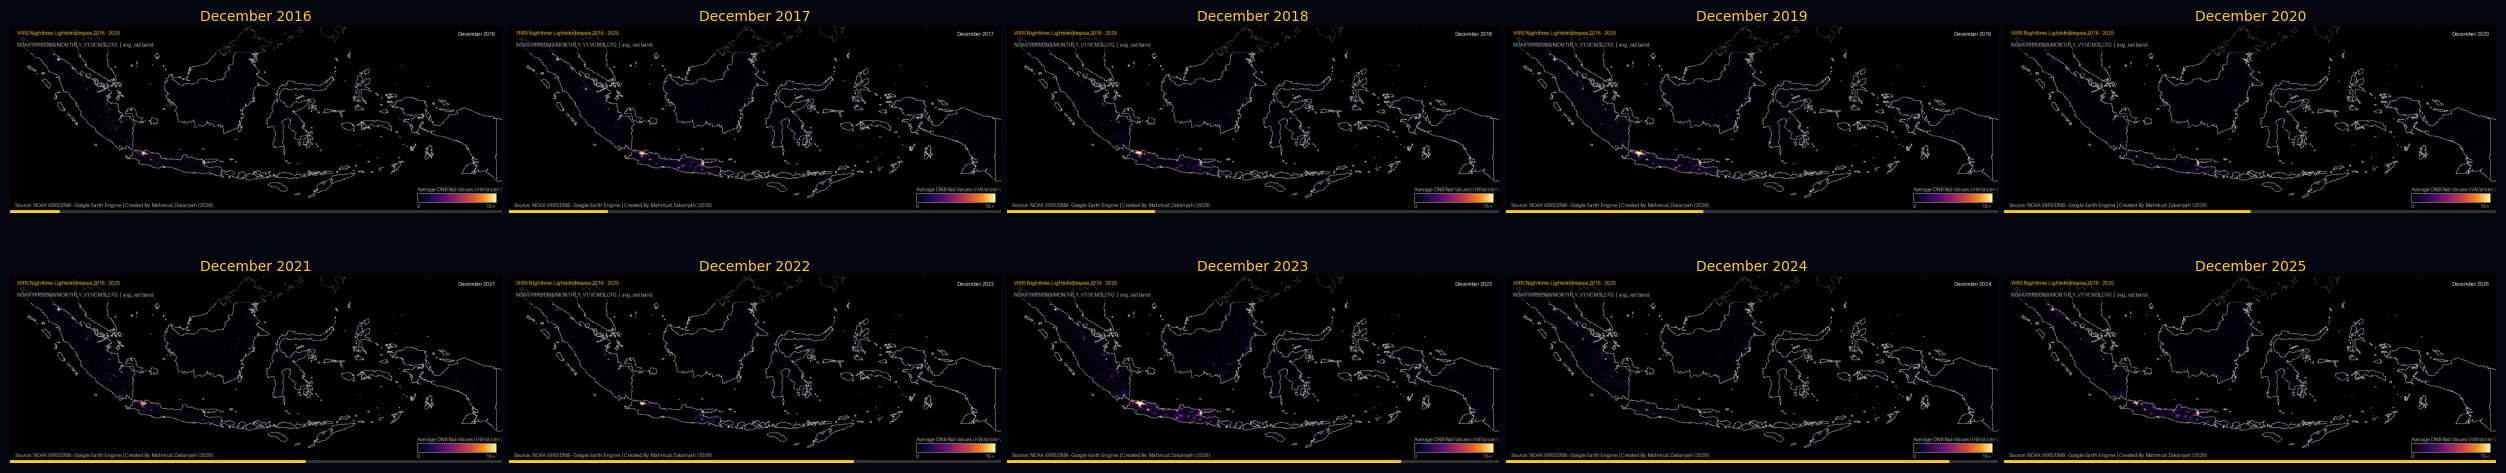

In [13]:
# Preview Individual Frames

# Display selected frames as a grid for inspection

from IPython.display import display

def preview_frames(frame_indices: list[int], cols: int = 3):
    """Display selected frames in a matplotlib grid."""
    rows = (len(frame_indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 5, rows * 2.8),
                             facecolor='#050510')
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for ax, idx in zip(axes, frame_indices):
        if idx < len(frames):
            year, month = timeline[idx]
            ax.imshow(frames[idx])
            ax.set_title(f"{BULAN[month-1]} {year}",
                         color='#ffcc33', fontsize=10, pad=4)
        ax.axis('off')

    for ax in axes[len(frame_indices):]:
        ax.set_visible(False)

    plt.tight_layout(pad=0.5)
    plt.show()

# Preview: December of each year (frames 11, 23, 35, ...)
december_frames = [y * 12 + 11 for y in range(END_YEAR - START_YEAR + 1)]
print("Preview — December of each year:")
preview_frames(december_frames, cols=5)


## Done

If all cells ran without errors, you now have:
- File **`viirs_indonesia_2016_2025_v1.gif`** — animated nighttime lights of Indonesia from January 2016 to December 2025 (120 frames, 0.3 seconds per frame)
- File **`viirs_indonesia_2016_2025_4K.mp4`** — MP4 version at 4K resolution (3840×1920), ~30 seconds, high quality
- Animation preview already displayed directly in the notebook (Cell 8)
- (Optional) Copies of the files on your local computer or in Google Drive

### Ideas for further development
- Replace `INDONESIA_BBOX` with coordinates of a specific province/city to zoom into a smaller area
- Add a chart showing the average radiation trend per year alongside the animation (e.g. a line chart of average `avg_rad` per month)
- Compare two adjacent regions (e.g. Java vs Kalimantan) side by side in a single frame for comparative analysis
- Switch the codec to `libx265` (H.265) for even smaller file sizes (requires ffmpeg with H.265 support)
- Add a watermark or logo in the corner of each frame using PIL
- Export at 8K resolution (7680×3840) for the highest presentation quality


In [14]:
# DONE

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VIIRS Nighttime Lights Indonesia — Animation Complete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 GIF Output : viirs_indonesia_2016_2025_v1.gif
 MP4 Output : viirs_indonesia_2016_2025_4K_v.mp4  (4K, H.264)
 Period     : January 2016 – December 2025
 Frames     : 120 (1 frame = 1 month, 0.3 sec/frame GIF)
 MP4 Length : ~30 seconds @ 4 fps
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VIIRS Nighttime Lights Indonesia — Animation Complete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 GIF Output : viirs_indonesia_2016_2025_v1.gif
 MP4 Output : viirs_indonesia_2016_2025_4K_v.mp4  (4K, H.264)
 Period     : January 2016 – December 2025
 Frames     : 120 (1 frame = 1 month, 0.3 sec/frame GIF)
 MP4 Length : ~30 seconds @ 4 fps
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

